# Representación por medio de Bag of Words

Dentro de este libro vamos a considerar el proceso de representar un texto por medio de la bolsa de palabras o BagofWords. Necesitamos tener un texto normalizado. Luego de normalizarlo y reducir el tamaño del vocabulario, representaremos las palabras por un vector tipo *one hot encoding*

Vamos a considerar el libro de Don Quijote para hacer un procesamiento del texto de manera normalizada. Vamos a llevar la información a algo estándar que se pueda procesar de la manera anterior de texto.

In [ ]:
!wget 'https://robertohincapie.com/data/quijote.txt' -q

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
with open('quijote.txt','rt') as file:
  lines=file.readlines()
print(lines[0:10])


['DON QUIJOTE DE LA MANCHA\n', 'Miguel de Cervantes Saavedra\n', '\n', 'PRIMERA PARTE\n', 'CAPÍTULO 1: Que trata de la condición y ejercicio del famoso hidalgo D. Quijote de la Mancha\n', 'En un lugar de la Mancha, de cuyo nombre no quiero acordarme, no ha mucho tiempo que vivía un hidalgo de los de lanza en astillero, adarga antigua, rocín flaco y galgo corredor. Una olla de algo más vaca que carnero, salpicón las más noches, duelos y quebrantos los sábados, lentejas los viernes, algún palomino de añadidura los domingos, consumían las tres partes de su hacienda. El resto della concluían sayo de velarte, calzas de velludo para las fiestas con sus pantuflos de lo mismo, los días de entre semana se honraba con su vellori de lo más fino. Tenía en su casa una ama que pasaba de los cuarenta, y una sobrina que no llegaba a los veinte, y un mozo de campo y plaza, que así ensillaba el rocín como tomaba la podadera. Frisaba la edad de nuestro hidalgo con los cincuenta años, er

In [ ]:
!pip install unidecode

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 21.8 MB/s eta 0:00:00


¿Por qué los caracteres con tilde generan problemas en Python (y otros lenguajes)?
En procesamiento de texto, especialmente con caracteres en español como á, é, ñ, etc., es común enfrentarse a errores sutiles al comparar, buscar o filtrar texto. Esto sucede porque los caracteres con tilde pueden representarse en Unicode de más de una forma, aunque visualmente parezcan iguales.

El problema: representaciones múltiples en Unicode
Tomemos como ejemplo la letra á. Esta puede representarse de dos formas distintas:

Forma compuesta (NFC): un único carácter Unicode.

'á' → U+00E1 (LATIN SMALL LETTER A WITH ACUTE)

Forma descompuesta (NFD): la letra base + un carácter de tilde por separado.

'a' (U+0061) + ´ (U+0301, COMBINING ACUTE ACCENT)

Aunque ambas formas se ven idénticas, sus representaciones internas son diferentes:

In [ ]:
#Este proceso lo hacemos para reducir el problema de la diferencia entre la representación y la visualización de caracteres con tildes.
import unicodedata
import re

def limpiar_texto_con_tildes(texto):
    texto = unicodedata.normalize('NFC', texto)
    texto = re.sub(r'[^a-zA-ZáéíóúÁÉÍÓÚüÜñÑ \n,:;.¿?]', '', texto)
    texto = texto.replace('\n', ' ').replace('\t', ' ')
    texto = re.sub(r'\s{2,}', ' ', texto)
    texto = texto.strip()
    return texto.lower()


Ahora utilizamos NLTK para apoyar el procesamiento

In [ ]:
#Importamos NLTK, y dentro de este el tokenizador, las stopWords y el stemmer
import string
import nltk
nltk.download("punkt")
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize
nltk.download('stopwords')
stopwords = nltk.corpus.stopwords.words("spanish")
from nltk.stem import SnowballStemmer
spanish_stemmer = SnowballStemmer('spanish')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
#Normalización, en resumen:
def normalizar(texto):
  texto=limpiar_texto_con_tildes(texto)
  lst=word_tokenize(texto) #separamos el texto en tokens
  lst2 = [token for token in lst if token not in stopwords] #Quitamos las palabras que son muy comunes.
  lst3 = [spanish_stemmer.stem(token) for token in lst2 if token not in string.punctuation and token not in stopwords and len(token)>2] #lematizamos, quitando los símbolos de puntuación y las palabras más pequeñas que 2
  return lst3

texto=' '.join(lines)
lst3=normalizar(texto)
print('Tamaño final del vocabulario: ',len(list(set(lst3))))


Tamaño final del vocabulario:  6707


Ahora vamos a crear como tal la bolsa de palabras. En este caso, se construye el diccionario de las palabras que quedaron luego de la limpieza y se hace el proceso de transformación de los textos.

Para esto se utiliza la función CountVectorizer de sklearn, que produce la matriz dispersa de la representación.

In [ ]:
#Creación de la bolsa de palabras
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer()

#Se ajusta el modelo de vectorizer a las palabras que se dejaron luego de la normalización
vectorizer.fit(lst3)

print("Vamos a mostrar el índice o posición de diferentes palabras del vocabulario")
cnt=5
for k,v in vectorizer.vocabulary_.items(): #esto corresponde al diccionario de las palabras encontradas.
  if(cnt>0):
    print(k,v)
  cnt-=1

# Acá representamos las palabras como tal por medio del Bag of Words. Esto lo podemos hacer sobre cualquier conjunto de palabras
bow_model = vectorizer.transform(lst3)

# Representemos ahora una de las palabras que se convirtieron, para mirar la representación dispersa
print(f'\nRepresentación de la primera palabra vimos arriba. Observe que es un vector que tiene un 1 en la misma posición del índice: {bow_model[0]}')



Vamos a mostrar el índice o posición de diferentes palabras del vocabulario
don 2280
quijot 5204
manch 4020
miguel 4197
cervant 1315

Representación de la primera palabra vimos arriba. Observe que es un vector que tiene un 1 en la misma posición del índice: <Compressed Sparse Row sparse matrix of dtype 'int64'
	with 1 stored elements and shape (1, 6664)>
  Coords	Values
  (0, 2280)	1


Hagamos el proceso de representación completo, primero normalizando el texto y luego pasándolo por la bolsa de palabras. Usted debe comprender que al final el vector representa un valor diferente de cero por cada palabra que aparezca.

Así mismo, una posición que tenga un valor mayor a 1, significa que la palabra aparece más de una vez en la frase.

Frase original a procesar:  Miguel es una persona que yo aprecio realmente y me gusta ir a su casa a compartir con la familia de Miguel

Frase normalizada, luego de todo el proceso: miguel person apreci realment gust cas compart famili miguel


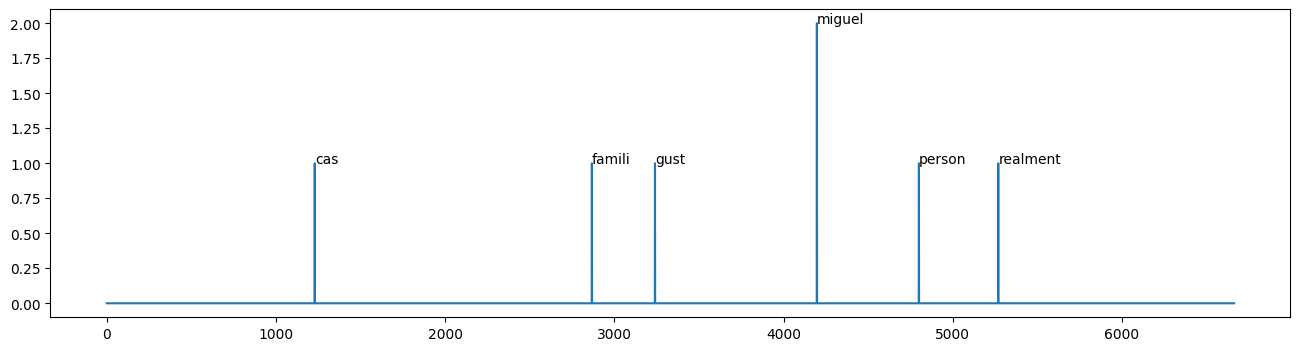

In [ ]:
frase = "Miguel es una persona que yo aprecio realmente y me gusta ir a su casa a compartir con la familia de Miguel"
print('Frase original a procesar: ', frase)
tokens_frase = normalizar(frase)
frase_normalizada = ' '.join(tokens_frase)
print(f'\nFrase normalizada, luego de todo el proceso: {frase_normalizada}')

#Convertimos la frase normalizada en un vector correspondiente a la representación de bolsa de palabras.
x = vectorizer.transform([frase_normalizada])

#Y finalmente mostramos la forma final del vector de representación
plt.figure(figsize=(16,4))
plt.plot(x.toarray()[0])

#Ubiquemos las etiquetas de las palabras que contiene la frase
for k,v in vectorizer.vocabulary_.items(): #esto corresponde al diccionario de las palabras encontradas.
  if(k in tokens_frase):
    plt.annotate(k, (v, x.toarray()[0][v]))
plt.show()

#Puede observar que hay palabras que no aparecen, esto es porque no están en el vocabulario inicial